## 6.2 神经网络参数优化 - 反向传播详细解释


#### 1. 反向传播是什么

##### 1.1 核心概念
反向传播（Backpropagation） 的本质就是：

`从最终的损失函数 Loss 开始，利用链式法则，反向计算出网络中每一层参数的梯度。`

这些梯度的作用是：
* 告诉我们每个参数应该往哪个方向调整
* 告诉我们每个参数调整多少会让 Loss 降低

所以反向传播并不是“另一个独立算法”，而是：

`神经网络中用来高效计算梯度的方法。`

##### 1.2 为什么需要反向传播
在神经网络中，参数很多很多：
* 第一层有一组权重和偏置
* 第二层有一组权重和偏置
* 第三层还有一组权重和偏置
* …

如果我们想用梯度下降更新参数，就必须先知道：

`每一层的各个参数的梯度`

也就是说：

`Loss 对每一层参数的偏导数是多少？`

而反向传播就是专门解决这个问题的。

##### 1.3 直观理解 🌟
可以把神经网络看成一条“加工流水线”：
```
输入 X
  ↓
第1层计算
  ↓
第2层计算
  ↓
第3层计算
  ↓
输出 ŷ
  ↓
计算 Loss
```

前向传播时，数据是 从前往后流动 的。

而反向传播时，误差信息是 从后往前流动 的。
* 前向传播：算输出
* 反向传播：算梯度

#### 2. 反向传播到底在“反向”什么

##### 2.1 不是把输入反着传一遍
反向传播 不是：
* 把 X 再倒着输回去

而是：
* 把 Loss 对后面变量的影响，
* 一层一层往前传递

也就是：
* 输出层先知道自己对 Loss 的影响
* 然后把这种影响传给前一层
* 前一层再继续往前传
* 最终每一层都能知道自己应该承担多少“责任”

##### 2.2 本质上在反向传播的是“梯度信息”
更准确地说，反向传播传播的是：
`每一层的梯度，因为每一层的参数W和b 都影响下一层的结果和损失，层层递进`

也就是：

`Loss 对各层中间变量和参数的偏导信息`

所以“反向传播”四个字，可以理解成：
`把损失对最终输出的影响，按链式法则一层层往前拆解。`


#### 3. 反向传播的数学基础：链式法则

##### 3.1 为什么必须依赖链式法则
神经网络本质上是一个 **复合函数**。
例如一个两层网络：
```
Z_1 = W_1 * X + b_1
A_1 = g(Z_1) # 激活函数

Z_2 = W_2 * A_1 + b_1
A_2 = g(Z_2) # 激活函数

Ŷ = A_2

Loss = Loss(A_2, Y)
```

会发现：
* Loss 依赖 Ŷ
* Ŷ 依赖 Z_2
* Z_2 依赖 A_1 + W_2 + b_2
* A_1 依赖 Z_1
* Z_1 依赖 W_1 + b_1

要想知道 L 对所有参数的导数，就必须一层一层往回拆，这就是链式法则。

##### 3.2 最简单的链式法则例子
```
sigmam = 2 * x

y = sigma ^ 2
```

此时 y 对于 x 的偏导数应该遵循链式法则：
```
(y/x) = (y/sigma) * (sigma/x)
      = 2 * sigma * 2 = 8 * x
```

这就是链式法则的核心思想：

`后面的导数 × 前面的导数 = 总导数`

神经网络里的反向传播，本质上就是把这个过程扩展到多层、多参数、矩阵形式。

#### 4. 反向传播中几个最重要的中间量
为了后面学习优化器、自动求导，一定要认识下面这几个量。

##### 4.1 ￼

![Screenshot 2026-03-12 at 11.33.27.png](<attachment:Screenshot 2026-03-12 at 11.33.27.png>)

表示：

![Screenshot 2026-03-12 at 11.33.40.png](<attachment:Screenshot 2026-03-12 at 11.33.40.png>)

含义：

`Loss 对第 l 层线性输出的梯度`

这是每层反向传播的核心中间量。
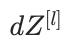
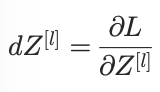

##### 4.2 

![Screenshot 2026-03-12 at 11.34.36.png](<attachment:Screenshot 2026-03-12 at 11.34.36.png>)

含义：

`Loss 对第 l 层权重矩阵的梯度`

这个量直接用于更新参数。
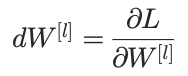

##### 4.3 

![Screenshot 2026-03-12 at 11.35.28.png](<attachment:Screenshot 2026-03-12 at 11.35.28.png>)

含义：
Loss 对第 l 层偏置的梯度
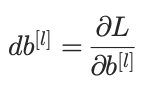

##### 4.4 

![Screenshot 2026-03-12 at 11.36.09.png](<attachment:Screenshot 2026-03-12 at 11.36.09.png>)

含义：

`Loss 对第 l 层激活输出的梯度`

它是梯度继续向前传播的桥梁
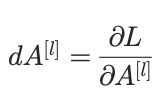

##### 5. 先用一个极简例子理解反向传播
我们先不急着进入矩阵，先用单个样本、单个神经元来理解。
假设：
```
z = w * x + b

ŷ = sigma(z)

L = (ŷ - y)^2 /2

```

这里：
* x：输入
* w：权重
* b：偏置
* ŷ：预测值
* y：真实值

我们的目标是求：
![Screenshot 2026-03-12 at 10.33.29.png](<attachment:Screenshot 2026-03-12 at 10.33.29.png>)
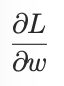

##### 5.1 先画依赖关系
```
w
 \
  → z → ŷ → L
 /
x
```
可以看到：
* L 不直接依赖 w
* L 是通过 z 和 ŷ 间接依赖 w

所以必须使用链式法则。

##### 5.2 按链式法则展开

![Screenshot 2026-03-12 at 10.45.40.png](<attachment:Screenshot 2026-03-12 at 10.45.40.png>)

分别计算：

**第一步：对预测值求导**

![Screenshot 2026-03-12 at 10.46.03.png](<attachment:Screenshot 2026-03-12 at 10.46.03.png>)

所以：

![Screenshot 2026-03-12 at 10.46.17.png](<attachment:Screenshot 2026-03-12 at 10.46.17.png>)

**第二步：激活函数求导**

![Screenshot 2026-03-12 at 10.46.50.png](<attachment:Screenshot 2026-03-12 at 10.46.50.png>)

所以：

![Screenshot 2026-03-12 at 10.47.01.png](<attachment:Screenshot 2026-03-12 at 10.47.01.png>)

**第三步：线性部分求导**

![z = wx + b.png](<attachment:z = wx + b.png>)

所以：

![Screenshot 2026-03-12 at 10.51.06.png](<attachment:Screenshot 2026-03-12 at 10.51.06.png>)

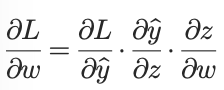
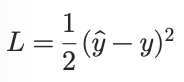
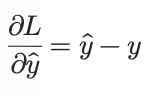
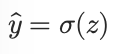
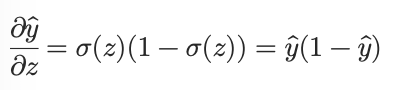
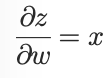
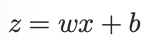

##### 5.3 合起来

![Screenshot 2026-03-12 at 10.51.19.png](<attachment:Screenshot 2026-03-12 at 10.51.19.png>)

同理：

![Screenshot 2026-03-12 at 10.51.33.png](<attachment:Screenshot 2026-03-12 at 10.51.33.png>)

这就是最基础的反向传播。
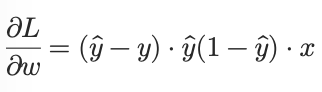
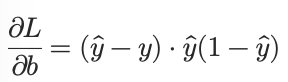

##### 5.4 这个例子说明了什么 💡
参数的梯度，不是直接从 Loss 一步得到的，

`而是沿着“Loss → 输出 → 中间变量 → 参数”这条路径一步一步传回来的。`

这就是“反向传播”的最原始含义。

#### 6. 神经网络中的反向传播流程
对于一个多层网络，训练一个 batch 时，整体流程是：

##### 6.1 前向传播
先算出：
* 每层的线性输出 Z
* 每层的激活输出 A
* 最终预测值 ŷ
* batch loss

##### 6.2 从 Loss 开始反向传播
从最后一层开始，逐层计算：

![Screenshot 2026-03-12 at 10.57.37.png](<attachment:Screenshot 2026-03-12 at 10.57.37.png>)

再继续传回前一层：

![Screenshot 2026-03-12 at 10.57.49.png](<attachment:Screenshot 2026-03-12 at 10.57.49.png>)

直到第一层。

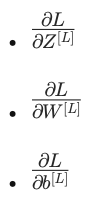
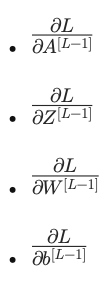

##### 6.3 更新参数
最后使用梯度下降：

![W! = W!' - aWI.png](<attachment:W! = W!' - aWI.png>)

![Screenshot 2026-03-12 at 10.58.45.png](<attachment:Screenshot 2026-03-12 at 10.58.45.png>)
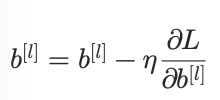
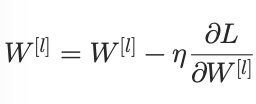

#### 7. 用两层网络详细理解反向传播
现在我们用一个最经典的两层 MLP 说明。

##### 7.1 前向传播定义
```
Z_1 = W_1 * X + b_1
A_1 = g(Z_1) # 激活函数

Z_2 = W_2 * A_1 + b_1
A_2 = g(Z_2) # 激活函数

Ŷ = A_2

Loss = Loss(A_2, Y)
```
其中：
* 第1层：隐藏层
* 第2层：输出层

##### 7.2 反向传播的顺序
反向传播顺序一定是：
```
Loss
↓
第2层
↓
第1层
```

也就是：
1. 输出层先求梯度
2. 再求隐藏层梯度

原因很简单：
1. 前一层的梯度，必须依赖后一层已经算出来的梯度。
2. 因为Z_2 = A_1 * W_2 + b_2
3. A_1的计算必须依赖W_2

##### 7.3 输出层的反向传播
第一步：求 Loss 对输出的导数
![Pasted Graphic.png](<attachment:Pasted Graphic.png>)

它表示：

`Loss 对输出层的梯度`

这是输出层反向传播的起点。

第二步：再求输出层激活函数的梯度

因为：

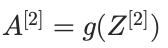

所以：

![Pasted Graphic 2.png](<attachment:Pasted Graphic 2.png>)

第三步：再求参数梯度

因为：

![Pasted Graphic 5.png](<attachment:Pasted Graphic 5.png>)

所以:

![Pasted Graphic 3.png](<attachment:Pasted Graphic 3.png>)

![Pasted Graphic 4.png](<attachment:Pasted Graphic 4.png>)

第四步：把梯度传回隐藏层

因为：

![Pasted Graphic 6.png](<attachment:Pasted Graphic 6.png>)

![Pasted Graphic 7.png](<attachment:Pasted Graphic 7.png>)
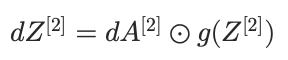
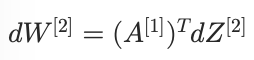
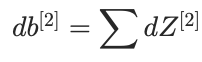
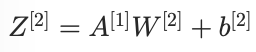
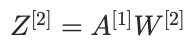
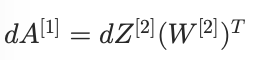
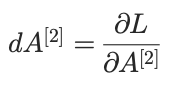

##### 7.4 隐藏层的反向传播
现在我们已经得到：

![Pasted Graphic 8.png](<attachment:Pasted Graphic 8.png>)

可以继续传播。

第一步：通过激活函数传播

因为：

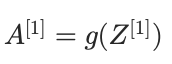

所以：

![Screenshot 2026-03-12 at 11.22.10.png](<attachment:Screenshot 2026-03-12 at 11.22.10.png>)

这一步非常关键：

激活函数会改变梯度的传递方式。

第二步：再求隐藏层线性部分参数梯度

因为：

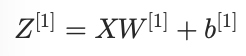

所以：

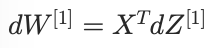

![Screenshot 2026-03-12 at 11.23.20.png](<attachment:Screenshot 2026-03-12 at 11.23.20.png>)

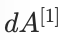
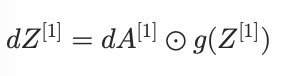
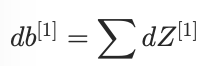

##### 7.5 🧠 把两层网络的反向传播串起来
前向传播
```
X
↓
Z1 = XW1 + b1
↓
A1 = g(Z1)
↓
Z2 = A1W2 + b2
↓
A2 = ŷ
↓
Loss
```

反向传播：
```
Loss
↓
dA2 = ∂L/∂A2
↓
dZ2 = dA2 ⊙ g'(Z2)
↓
dW2 , db2
↓
dA1 = dZ2 W2ᵀ
↓
dZ1 = dA1 ⊙ g'(Z1)
↓
dW1 , db1
```

#### 8. Batch 下的反向传播如何理解

##### 8.1 batch 中所有样本共享同一套参数
对于一个 batch：
* 所有样本共同使用同一个 W^{[1]}, W^{[2]}, ...
* 前向传播时一起做矩阵运算
* 反向传播时一起计算梯度


##### 8.2 batch loss 是一个标量
一个 batch 中，每个样本有自己的 loss：

![Screenshot 2026-03-12 at 11.31.33.png](<attachment:Screenshot 2026-03-12 at 11.31.33.png>)

通常：

![Screenshot 2026-03-12 at 11.31.43.png](<attachment:Screenshot 2026-03-12 at 11.31.43.png>)

然后从这个标量开始反向传播。

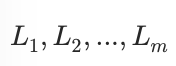
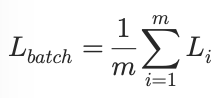

##### 8.3 batch 梯度本质上是平均梯度
对 batch loss 求导：

![Screenshot 2026-03-12 at 11.32.06.png](<attachment:Screenshot 2026-03-12 at 11.32.06.png>)

所以：

`一个 batch 的梯度，本质上就是这个 batch 中所有样本梯度的平均。`
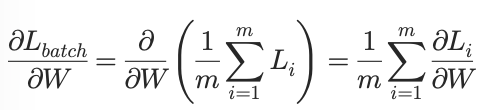

#### 9. 为什么激活函数在反向传播中很重要
激活函数不仅在前向传播中引入非线性，在反向传播中也直接影响梯度。

例如：

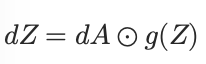

这里的 g'(Z) 就决定了：
* 梯度是被放大
* 被缩小
* 还是直接截断

所以不同激活函数会影响训练效果。

比如：

1️⃣ Sigmoid

`导数最大只有 0.25，容易梯度变小。`

2️⃣ Tanh

`比 Sigmoid 好一些，但深层中也可能梯度衰减。`

3️⃣ ReLU

`正区间导数为 1，梯度传播通常更稳定，所以深度学习中非常常用。`

#### 10. 在框架中反向传播是怎么实现的
以 PyTorch 为例：
```
y_pred = model(x)
loss = criterion(y_pred, y)
loss.backward()
optimizer.step()
optimizer.zero_grad()
```

1️⃣ loss.backward()

作用：

`自动执行反向传播，计算所有参数的梯度`

例如：
* W.grad
* b.grad

2️⃣ optimizer.step()

作用：

`根据梯度更新参数`

3️⃣ optimizer.zero_grad()

作用：

`清空旧梯度，避免梯度累加`